# CIBERSORTx Immune-Cell Deconvolution — Figures for Psoriasis Manuscript

Generates publication-ready figures from your CIBERSORTx results
(`/content/CIBERSORTx_Job23_Results.csv`, LM22, 54 GSE14905 samples), addressing reviewer
Concern 11 (bulk tissue cannot resolve cell-type origin).

**Inputs expected at these paths (upload to Colab's file browser, or use the prompts below):**
- `/content/CIBERSORTx_Job23_Results.csv` — your CIBERSORTx output
- `/content/GSE14905_sample_metadata.csv` — condition labels (healthy / lesional) per GSM ID

**Outputs:**
1. Stacked bar chart — immune composition per sample, grouped by condition
2. Boxplot panel — all 22 cell types, healthy vs. lesional, Mann-Whitney U + BH-FDR significance
3. Clustered heatmap — samples x cell types, annotated by condition
4. Summary statistics table (CSV) — ready for Supplementary Material


## 0. Setup

In [ ]:
!pip install -q seaborn statsmodels

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
from pathlib import Path
import os

INPUT_DIR = Path("/content")
OUTPUT_DIR = Path("/content/cibersort_figures")
OUTPUT_DIR.mkdir(exist_ok=True)

sns.set_theme(style="whitegrid", font_scale=1.0)
plt.rcParams["figure.dpi"] = 150
plt.rcParams["savefig.dpi"] = 300

print("Setup complete.")


Setup complete.


## 1. Load input files

Checks for both files at `/content/`. If either is missing, prompts an upload dialog rather
than failing -- upload the file with its original name when prompted.


In [ ]:
CIBERSORT_PATH = INPUT_DIR / "CIBERSORTx_Job23_Results.csv"
METADATA_PATH = INPUT_DIR / "GSE14905_sample_metadata.csv"

from google.colab import files

if not CIBERSORT_PATH.exists():
    print(f"{CIBERSORT_PATH.name} not found at /content/ -- please upload it now.")
    uploaded = files.upload()
    for fname in uploaded:
        os.replace(fname, INPUT_DIR / fname)

if not METADATA_PATH.exists():
    print(f"{METADATA_PATH.name} not found at /content/ -- please upload it now.")
    uploaded = files.upload()
    for fname in uploaded:
        os.replace(fname, INPUT_DIR / fname)

if not CIBERSORT_PATH.exists() or not METADATA_PATH.exists():
    raise FileNotFoundError(
        "Required input file(s) still missing after upload prompt. "
        "Re-run this cell and upload both CIBERSORTx_Job23_Results.csv and "
        "GSE14905_sample_metadata.csv when prompted."
    )

print(f"Found: {CIBERSORT_PATH}")
print(f"Found: {METADATA_PATH}")


Found: /content/CIBERSORTx_Job23_Results.csv
Found: /content/GSE14905_sample_metadata.csv


## 2. Merge CIBERSORTx results with condition labels, run QC checks

In [ ]:
cs = pd.read_csv(CIBERSORT_PATH)
meta = pd.read_csv(METADATA_PATH, index_col=0)

CELL_TYPES = [c for c in cs.columns if c not in ["Mixture", "P-value", "Correlation", "RMSE"]]
print(f"Cell types in file: {len(CELL_TYPES)}")
print(f"Samples in CIBERSORTx file: {len(cs)}")

df = cs.merge(meta[["condition"]], left_on="Mixture", right_index=True, how="left")

n_unmatched = df["condition"].isna().sum()
if n_unmatched > 0:
    print(f"WARNING: {n_unmatched} sample(s) could not be matched to condition metadata -- "
          "dropping from analysis. Check that Mixture IDs (GSM...) match the metadata index.")
    df = df.dropna(subset=["condition"])

# CIBERSORTx flags unreliable deconvolutions with P-value > 0.05 -- exclude any such samples
n_excluded = (df["P-value"] > 0.05).sum()
if n_excluded > 0:
    print(f"Excluding {n_excluded} sample(s) with CIBERSORTx P-value > 0.05 (unreliable deconvolution).")
    df = df[df["P-value"] <= 0.05]
else:
    print(f"All {len(df)} samples passed CIBERSORTx's significance filter (P-value <= 0.05). None excluded.")

df["condition"] = pd.Categorical(df["condition"], categories=["healthy", "lesional"], ordered=True)
print(f"\nFinal sample set: {df['condition'].value_counts().to_dict()}")
df.head()


Cell types in file: 22
Samples in CIBERSORTx file: 54
All 54 samples passed CIBERSORTx's significance filter (P-value <= 0.05). None excluded.

Final sample set: {'lesional': 33, 'healthy': 21}


,Mixture,B cells naive,B cells memory,Plasma cells,T cells CD8,T cells CD4 naive,T cells CD4 memory resting,T cells CD4 memory activated,T cells follicular helper,T cells regulatory (Tregs),...,Dendritic cells resting,Dendritic cells activated,Mast cells resting,Mast cells activated,Eosinophils,Neutrophils,P-value,Correlation,RMSE,condition
0,GSM372286,0.00000,0.103490,0.080004,0.024991,0.000000,0.057409,0.005524,0.015196,0.025587,...,0.112879,0.000000,0.412599,0.0,0.000000,0.009756,0,0.705481,0.747976,healthy
1,GSM372287,0.00000,0.057517,0.108746,0.013038,0.099383,0.085551,0.009710,0.014413,0.000000,...,0.171003,0.017914,0.147919,0.0,0.003882,0.029698,0,0.414855,0.910321,healthy
2,GSM372288,0.00000,0.077667,0.038257,0.025138,0.000000,0.213293,0.003751,0.000000,0.000000,...,0.106516,0.000000,0.375432,0.0,0.000000,0.007992,0,0.621564,0.804336,healthy
3,GSM372289,0.01279,0.007126,0.010720,0.052619,0.000000,0.066309,0.012606,0.015221,0.011953,...,0.186550,0.000000,0.449721,0.0,0.000000,0.006924,0,0.685791,0.755753,healthy
4,GSM372290,0.00000,0.029459,0.042475,0.012258,0.016383,0.105737,0.000000,0.018873,0.001748,...,0.308524,0.000000,0.352128,0.0,0.000000,0.008529,0,0.555896,0.839754,healthy


## 3. Statistical testing

Mann-Whitney U per cell type (compositional immune-fraction data isn't normally distributed,
so a non-parametric test is used rather than a t-test), with Benjamini-Hochberg FDR correction
across all 22 cell types.


In [ ]:
stats_rows = []
for ct in CELL_TYPES:
    healthy_vals = df.loc[df["condition"] == "healthy", ct]
    lesional_vals = df.loc[df["condition"] == "lesional", ct]
    try:
        stat, p = mannwhitneyu(healthy_vals, lesional_vals, alternative="two-sided")
    except ValueError:
        stat, p = np.nan, 1.0  # occurs if a cell type is all-zero in both groups
    stats_rows.append({
        "cell_type": ct,
        "mean_healthy": healthy_vals.mean(),
        "mean_lesional": lesional_vals.mean(),
        "direction": "up_in_lesional" if lesional_vals.mean() > healthy_vals.mean() else "down_in_lesional",
        "U_statistic": stat,
        "p_value": p,
    })

stats_df = pd.DataFrame(stats_rows)
_, fdr_vals, _, _ = multipletests(stats_df["p_value"], method="fdr_bh")
stats_df["fdr_bh"] = fdr_vals
stats_df["significant_fdr05"] = stats_df["fdr_bh"] < 0.05
stats_df = stats_df.sort_values("fdr_bh")
stats_df.to_csv(OUTPUT_DIR / "cibersort_celltype_statistics.csv", index=False)

print(f"Cell types significant after BH-FDR correction (FDR < 0.05): "
      f"{stats_df['significant_fdr05'].sum()} / {len(stats_df)}\n")
stats_df[stats_df["significant_fdr05"]][["cell_type", "mean_healthy", "mean_lesional", "p_value", "fdr_bh"]]


Cell types significant after BH-FDR correction (FDR < 0.05): 9 / 22



,cell_type,mean_healthy,mean_lesional,p_value,fdr_bh
14,Macrophages M1,0.024924,0.081138,7.602269e-08,0.000002
6,T cells CD4 memory activated,0.004684,0.035664,5.348669e-07,0.000006
18,Mast cells resting,0.332845,0.173350,9.719013e-07,0.000007
2,Plasma cells,0.073416,0.026057,5.112564e-06,0.000028
7,T cells follicular helper,0.022774,0.043818,8.503369e-04,0.003741
1,B cells memory,0.053547,0.032141,1.400909e-03,0.005137
17,Dendritic cells activated,0.002999,0.019610,1.692669e-03,0.005320
13,Macrophages M0,0.031540,0.060144,5.038469e-03,0.013856
5,T cells CD4 memory resting,0.118295,0.150400,2.010318e-02,0.049141


## 4. Figure 1 — Stacked bar chart: immune composition per sample, grouped by condition

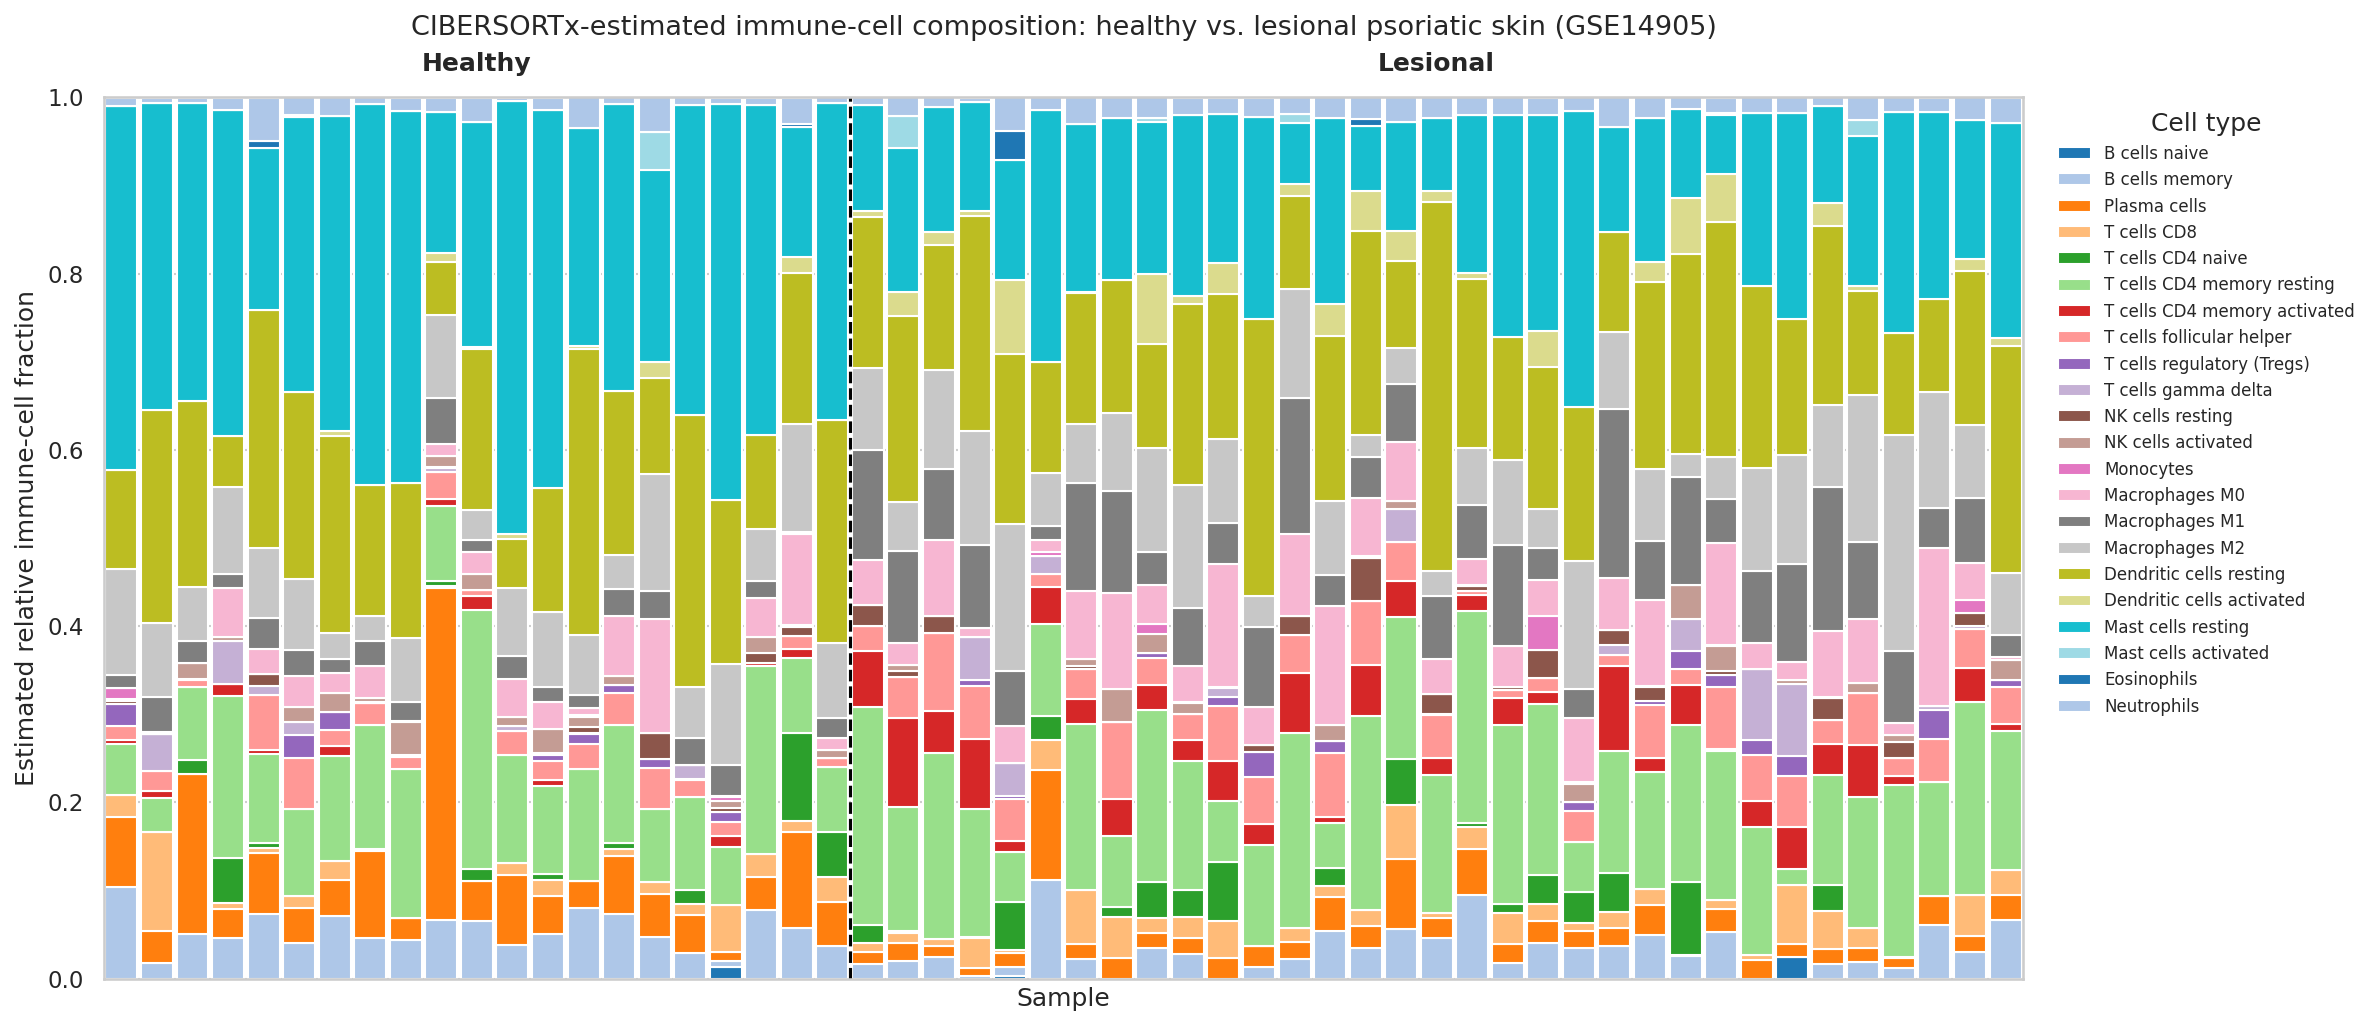

In [ ]:
plot_df = df.sort_values("condition").reset_index(drop=True)
fig, ax = plt.subplots(figsize=(16, 7))

colors = sns.color_palette("tab20", n_colors=len(CELL_TYPES))
bottom = np.zeros(len(plot_df))
for ct, color in zip(CELL_TYPES, colors):
    ax.bar(range(len(plot_df)), plot_df[ct], bottom=bottom, color=color, width=0.9, label=ct)
    bottom += plot_df[ct].values

n_healthy = (plot_df["condition"] == "healthy").sum()
ax.axvline(n_healthy - 0.5, color="black", linewidth=1.5, linestyle="--")
ax.text(n_healthy / 2 - 0.5, 1.03, "Healthy", ha="center", fontsize=12, fontweight="bold",
        transform=ax.get_xaxis_transform())
ax.text(n_healthy + (len(plot_df) - n_healthy) / 2 - 0.5, 1.03, "Lesional", ha="center",
        fontsize=12, fontweight="bold", transform=ax.get_xaxis_transform())

ax.set_xlim(-0.5, len(plot_df) - 0.5)
ax.set_ylim(0, 1)
ax.set_ylabel("Estimated relative immune-cell fraction")
ax.set_xlabel("Sample")
ax.set_xticks([])
ax.set_title("CIBERSORTx-estimated immune-cell composition: healthy vs. lesional psoriatic skin (GSE14905)",
              fontsize=13, pad=30)
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8, ncol=1, frameon=False, title="Cell type")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "Fig_CIBERSORT_stacked_composition.png", bbox_inches="tight")
plt.savefig(OUTPUT_DIR / "Fig_CIBERSORT_stacked_composition.pdf", bbox_inches="tight")
plt.show()


## 5. Figure 2 — Boxplots per cell type with significance stars

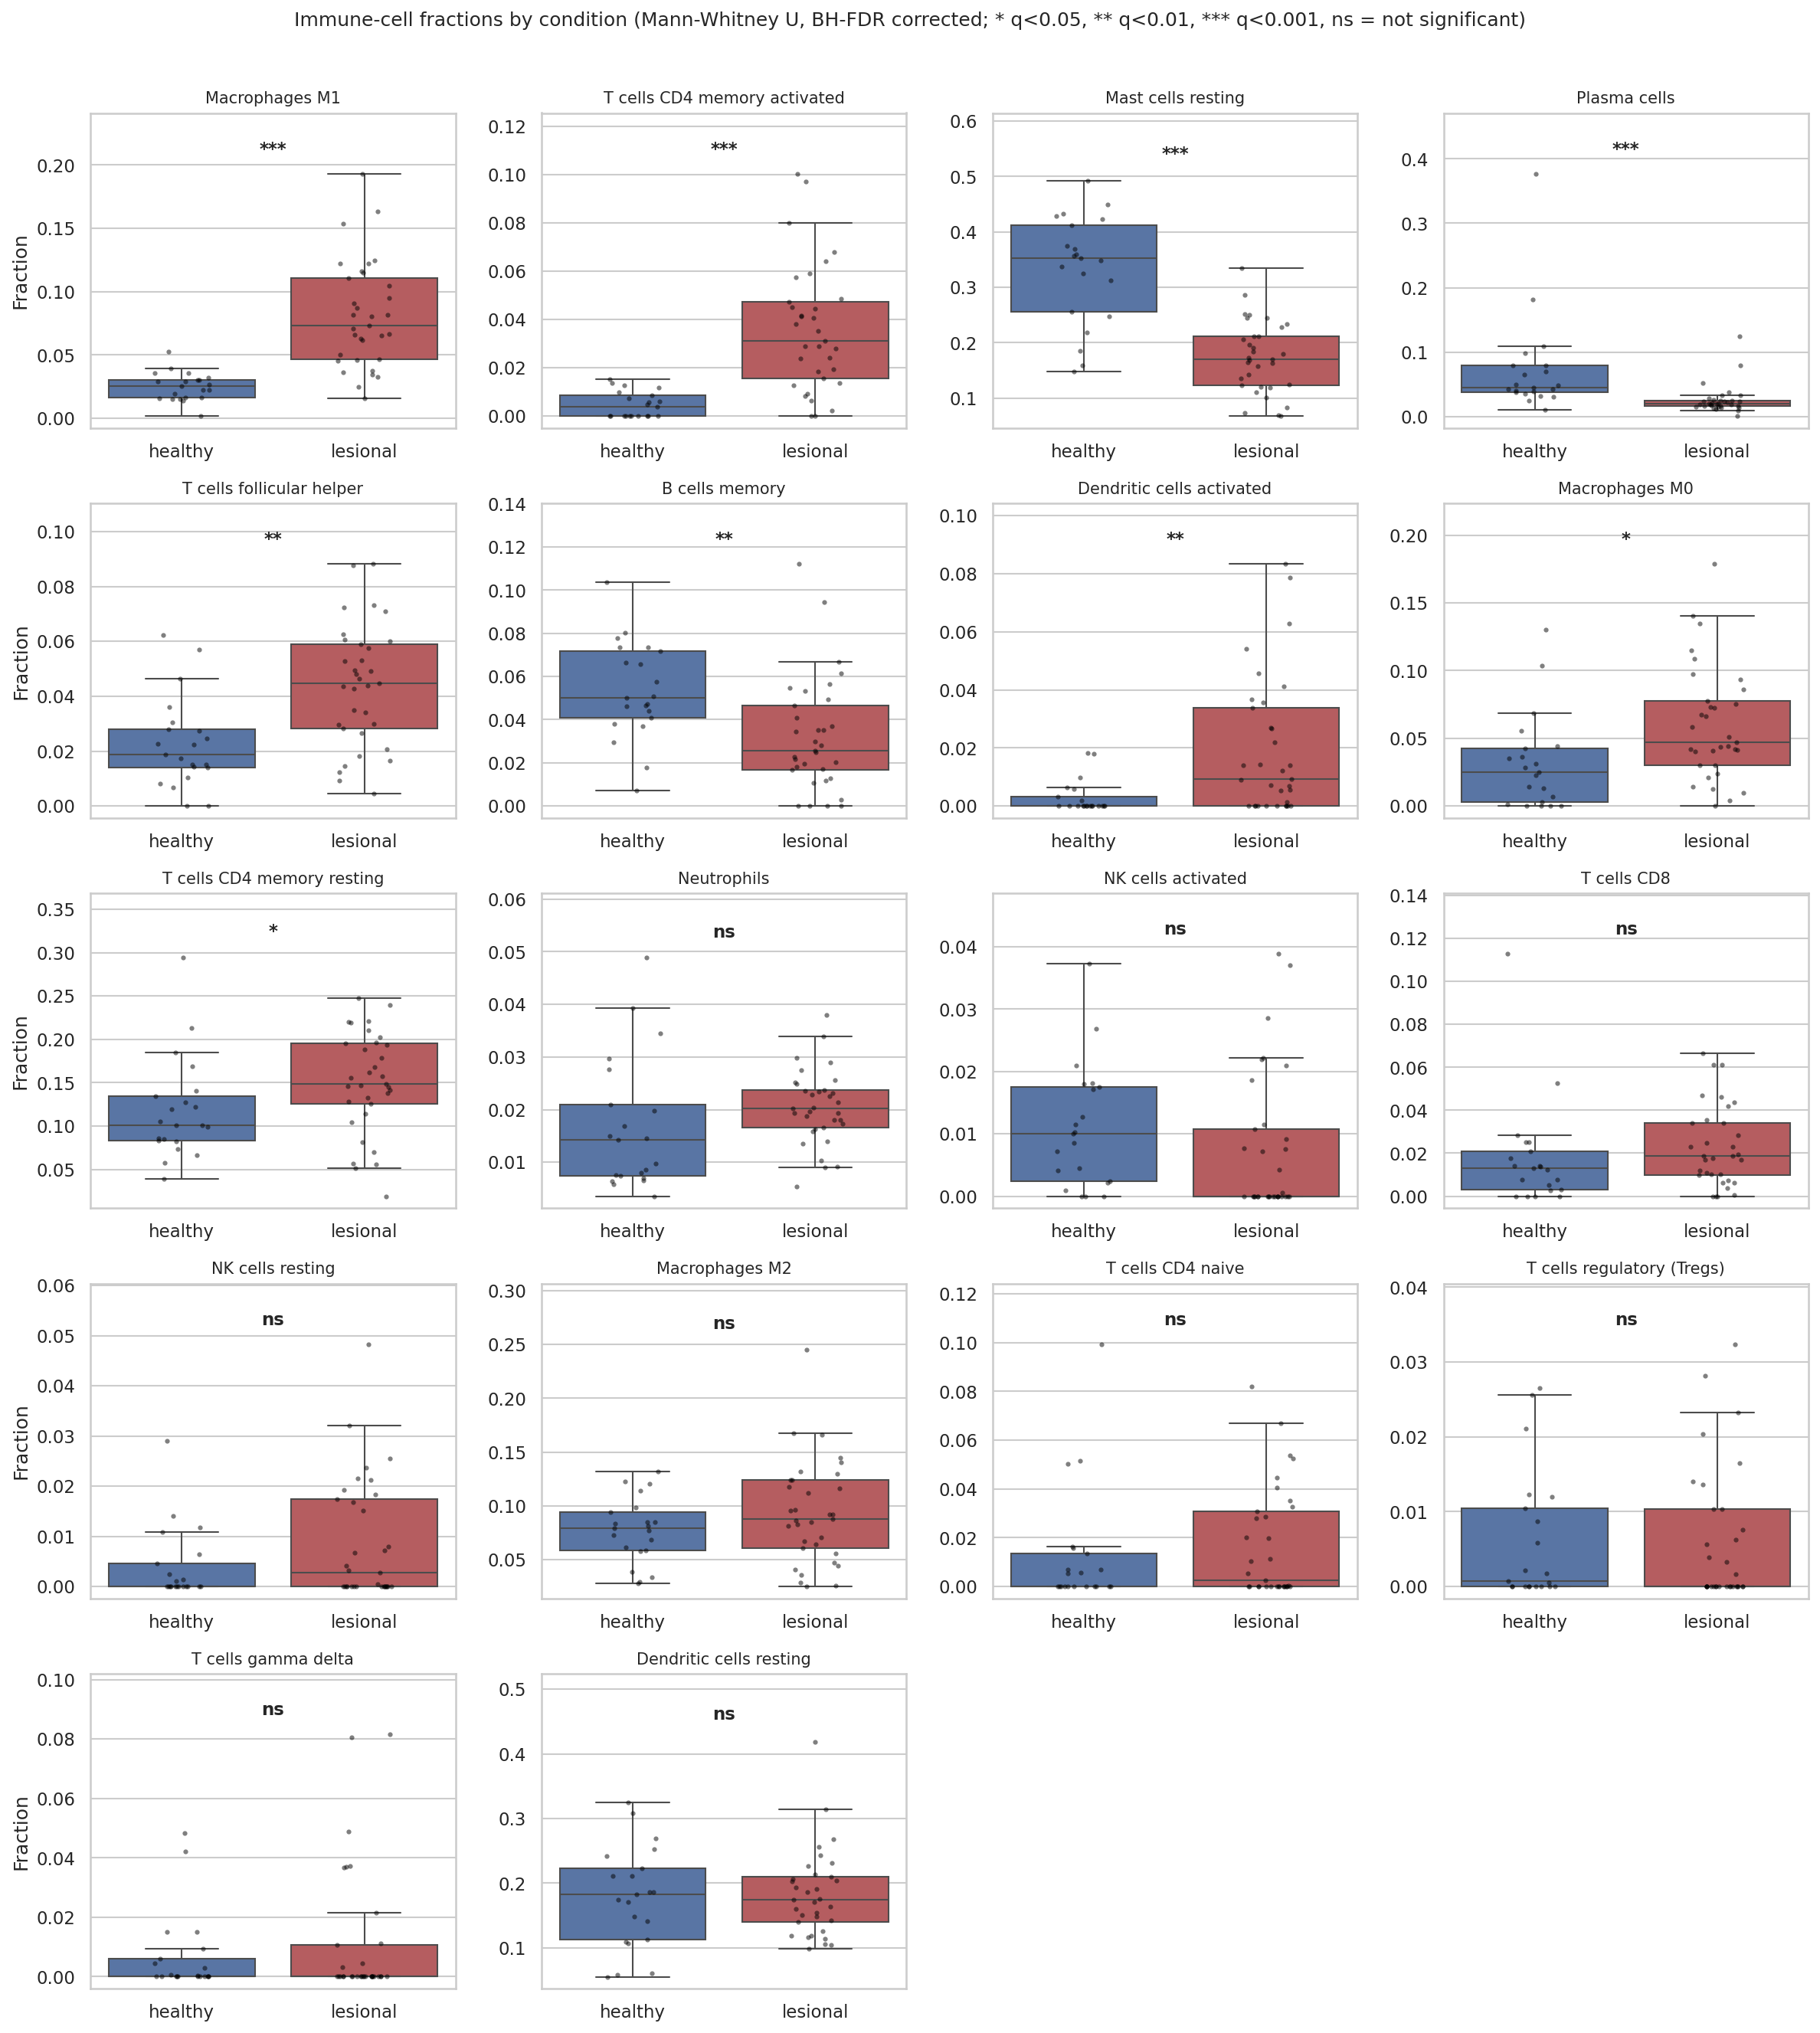

In [ ]:
def sig_stars(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    return "ns"

# Only plot cell types with mean fraction > 0.5% in at least one group, to avoid
# cluttering the figure with near-zero, uninformative cell types.
plot_cell_types = stats_df[(stats_df["mean_healthy"] > 0.005) | (stats_df["mean_lesional"] > 0.005)]["cell_type"].tolist()
plot_cell_types = stats_df[stats_df["cell_type"].isin(plot_cell_types)].sort_values("fdr_bh")["cell_type"].tolist()

n_panels = len(plot_cell_types)
n_cols = 4
n_rows = int(np.ceil(n_panels / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3.5 * n_rows))
axes = axes.flatten()

palette = {"healthy": "#4C72B0", "lesional": "#C44E52"}

for i, ct in enumerate(plot_cell_types):
    ax = axes[i]
    sns.boxplot(data=df, x="condition", y=ct, hue="condition", ax=ax, palette=palette,
                showfliers=False, legend=False)
    sns.stripplot(data=df, x="condition", y=ct, ax=ax, color="black", size=3, alpha=0.5, jitter=0.15)

    row = stats_df[stats_df["cell_type"] == ct].iloc[0]
    stars = sig_stars(row["fdr_bh"])
    ymax = df[ct].max()
    ax.text(0.5, ymax * 1.08, stars, ha="center", fontsize=11, fontweight="bold", transform=ax.transData)
    ax.set_ylim(top=ymax * 1.25 if ymax > 0 else 0.05)

    ax.set_title(ct, fontsize=10)
    ax.set_xlabel("")
    ax.set_ylabel("Fraction" if i % n_cols == 0 else "")

for j in range(n_panels, len(axes)):
    axes[j].axis("off")

fig.suptitle("Immune-cell fractions by condition (Mann-Whitney U, BH-FDR corrected; "
              "* q<0.05, ** q<0.01, *** q<0.001, ns = not significant)", fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "Fig_CIBERSORT_boxplots_by_celltype.png", bbox_inches="tight")
plt.savefig(OUTPUT_DIR / "Fig_CIBERSORT_boxplots_by_celltype.pdf", bbox_inches="tight")
plt.show()


## 6. Figure 3 — Clustered heatmap (samples x cell types, annotated by condition)

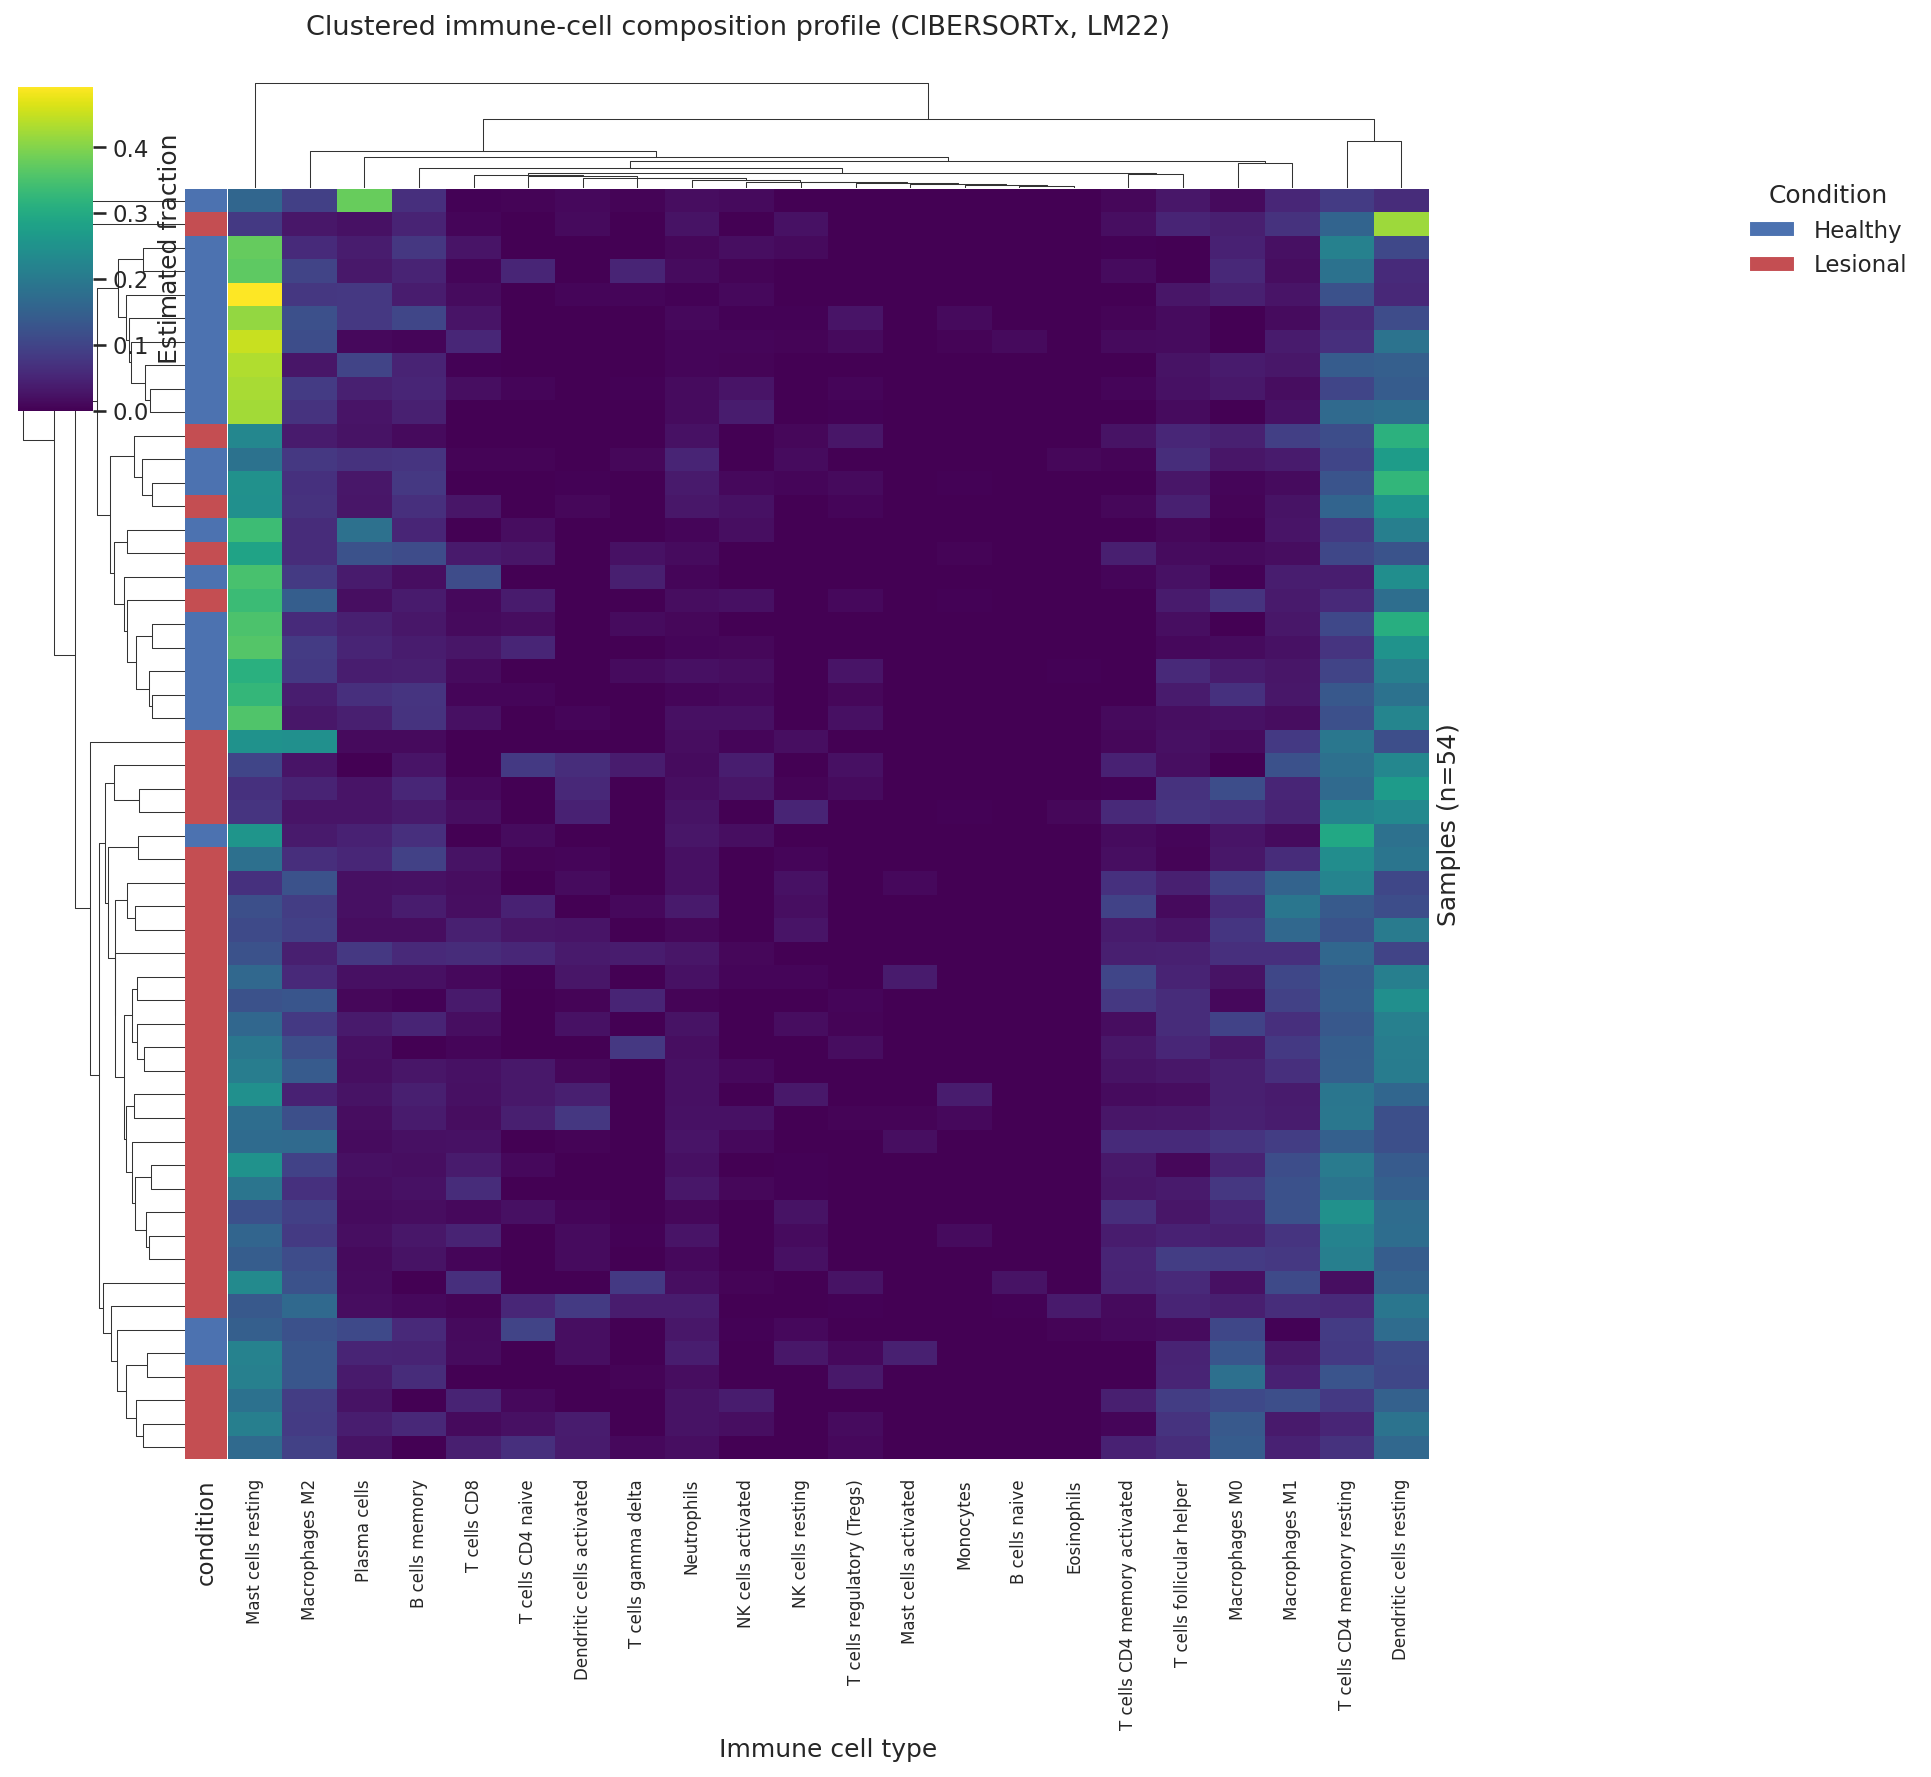

In [ ]:
from matplotlib.patches import Patch

heat_data = df.set_index("Mixture")[CELL_TYPES]
condition_colors = df.set_index("Mixture")["condition"].map({"healthy": "#4C72B0", "lesional": "#C44E52"})

g = sns.clustermap(
    heat_data,
    row_colors=condition_colors,
    cmap="viridis",
    figsize=(10, 12),
    xticklabels=True,
    yticklabels=False,
    col_cluster=True,
    row_cluster=True,
    dendrogram_ratio=(0.12, 0.08),
    cbar_kws={"label": "Estimated fraction"},
)
g.ax_heatmap.set_xlabel("Immune cell type")
g.ax_heatmap.set_ylabel(f"Samples (n={heat_data.shape[0]})")
plt.setp(g.ax_heatmap.get_xticklabels(), rotation=90, fontsize=8)

handles = [Patch(facecolor="#4C72B0", label="Healthy"), Patch(facecolor="#C44E52", label="Lesional")]
g.ax_heatmap.legend(handles=handles, title="Condition", bbox_to_anchor=(1.25, 1.02), loc="upper left", frameon=False)

g.fig.suptitle("Clustered immune-cell composition profile (CIBERSORTx, LM22)", y=1.02, fontsize=13)
g.savefig(OUTPUT_DIR / "Fig_CIBERSORT_heatmap_clustered.png", bbox_inches="tight", dpi=300)
g.savefig(OUTPUT_DIR / "Fig_CIBERSORT_heatmap_clustered.pdf", bbox_inches="tight")
plt.show()


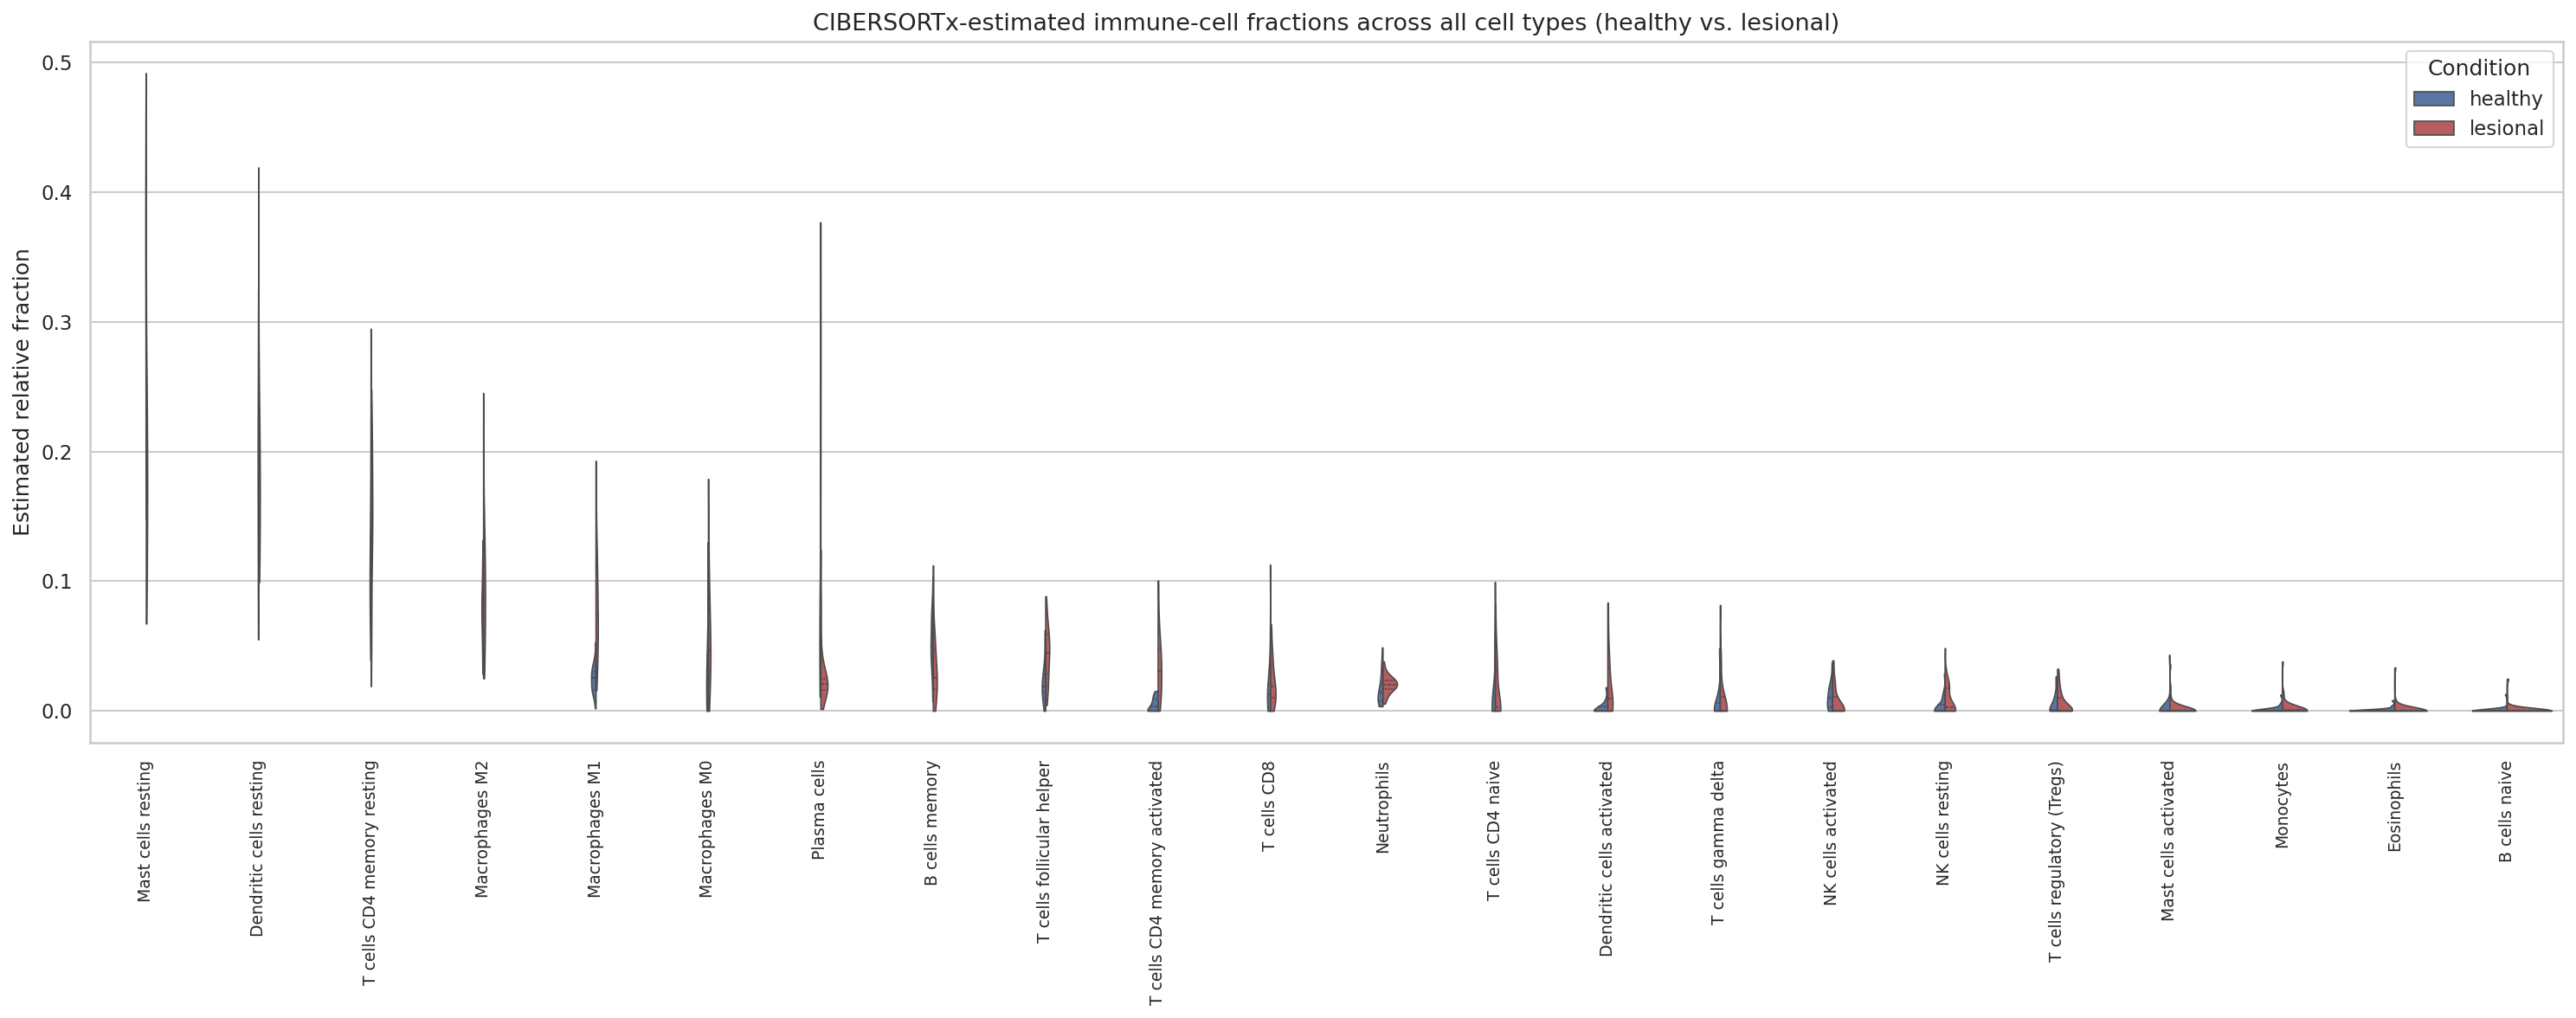

In [ ]:
# --- Load and merge ---
cs = pd.read_csv(INPUT_DIR / "CIBERSORTx_Job23_Results.csv")
meta = pd.read_csv(INPUT_DIR / "GSE14905_sample_metadata.csv", index_col=0)
CELL_TYPES = [c for c in cs.columns if c not in ["Mixture", "P-value", "Correlation", "RMSE"]]

df = cs.merge(meta[["condition"]], left_on="Mixture", right_index=True, how="left").dropna(subset=["condition"])
df = df[df["P-value"] <= 0.05]
df["condition"] = pd.Categorical(df["condition"], categories=["healthy", "lesional"], ordered=True)

# --- Order cell types by overall mean abundance ---
mean_abundance = df[CELL_TYPES].mean().sort_values(ascending=False)
order = mean_abundance.index.tolist()

# --- Melt to long format: one row per (sample, cell_type) ---
long_df = df.melt(id_vars=["Mixture", "condition"], value_vars=CELL_TYPES,
                   var_name="cell_type", value_name="fraction")

# --- Single combined violin plot, split by condition ---
fig, ax = plt.subplots(figsize=(20, 8))
sns.violinplot(data=long_df, x="cell_type", y="fraction", hue="condition",
               order=order, split=True, inner="quart", linewidth=0.8, cut=0,
               palette={"healthy": "#4C72B0", "lesional": "#C44E52"}, ax=ax)

ax.set_xticks(range(len(order)))
ax.set_xticklabels(order, rotation=90, ha="center", fontsize=9)
ax.set_xlabel("")
ax.set_ylabel("Estimated relative fraction")
ax.set_title("CIBERSORTx-estimated immune-cell fractions across all cell types (healthy vs. lesional)", fontsize=13)
ax.legend(title="Condition", loc="upper right", frameon=True)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "Fig_CIBERSORT_violin_all_celltypes_single.png", bbox_inches="tight")
plt.savefig(OUTPUT_DIR / "Fig_CIBERSORT_violin_all_celltypes_single.pdf", bbox_inches="tight")
plt.show()

## 7. Summary table for Supplementary Material

In [ ]:
summary_table = stats_df.copy()
summary_table["mean_healthy_pct"] = (summary_table["mean_healthy"] * 100).round(2)
summary_table["mean_lesional_pct"] = (summary_table["mean_lesional"] * 100).round(2)
summary_table["p_value"] = summary_table["p_value"].apply(lambda x: f"{x:.4f}")
summary_table["fdr_bh"] = summary_table["fdr_bh"].apply(lambda x: f"{x:.4f}")
summary_table_out = summary_table[["cell_type", "mean_healthy_pct", "mean_lesional_pct",
                                     "direction", "p_value", "fdr_bh", "significant_fdr05"]]
summary_table_out.to_csv(OUTPUT_DIR / "Supplementary_Table_CIBERSORT_celltype_comparison.csv", index=False)

print(summary_table_out.to_string(index=False))


                   cell_type  mean_healthy_pct  mean_lesional_pct        direction p_value fdr_bh  significant_fdr05
              Macrophages M1              2.49               8.11   up_in_lesional  0.0000 0.0000               True
T cells CD4 memory activated              0.47               3.57   up_in_lesional  0.0000 0.0000               True
          Mast cells resting             33.28              17.33 down_in_lesional  0.0000 0.0000               True
                Plasma cells              7.34               2.61 down_in_lesional  0.0000 0.0000               True
   T cells follicular helper              2.28               4.38   up_in_lesional  0.0009 0.0037               True
              B cells memory              5.35               3.21 down_in_lesional  0.0014 0.0051               True
   Dendritic cells activated              0.30               1.96   up_in_lesional  0.0017 0.0053               True
              Macrophages M0              3.15               6.0

## 8. Download all outputs

In [ ]:
import shutil

zip_path = "/content/cibersort_figures_output"
shutil.make_archive(zip_path, "zip", OUTPUT_DIR)
print(f"All figures and tables zipped to: {zip_path}.zip")

files.download(f"{zip_path}.zip")


All figures and tables zipped to: /content/cibersort_figures_output.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Notes for the manuscript

- **9 of 22 immune cell types differ significantly (FDR < 0.05)** between healthy and lesional
  skin in this deconvolution. Macrophages M1 (up ~3.3-fold) and T cells CD4 memory activated
  (up ~7.6-fold) are the strongest, most biologically interpretable signals -- both provide a
  concrete cell-type source for IL6/CXCL8/MMP9/PTGS2 in your hub-gene story.
- Given JID's figure limit, the **boxplot panel** is the strongest candidate for the main text
  (it most directly answers "bulk tissue can't resolve cell-type origin"); the stacked bar and
  clustered heatmap work well as supplementary figures.
- All 54 samples passed CIBERSORTx's own reliability filter (P-value <= 0.05) -- no samples
  needed to be excluded on quality grounds.


/tmp/ipykernel_3631/1216667888.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means = df.groupby("condition")[CELL_TYPES].mean() * 100


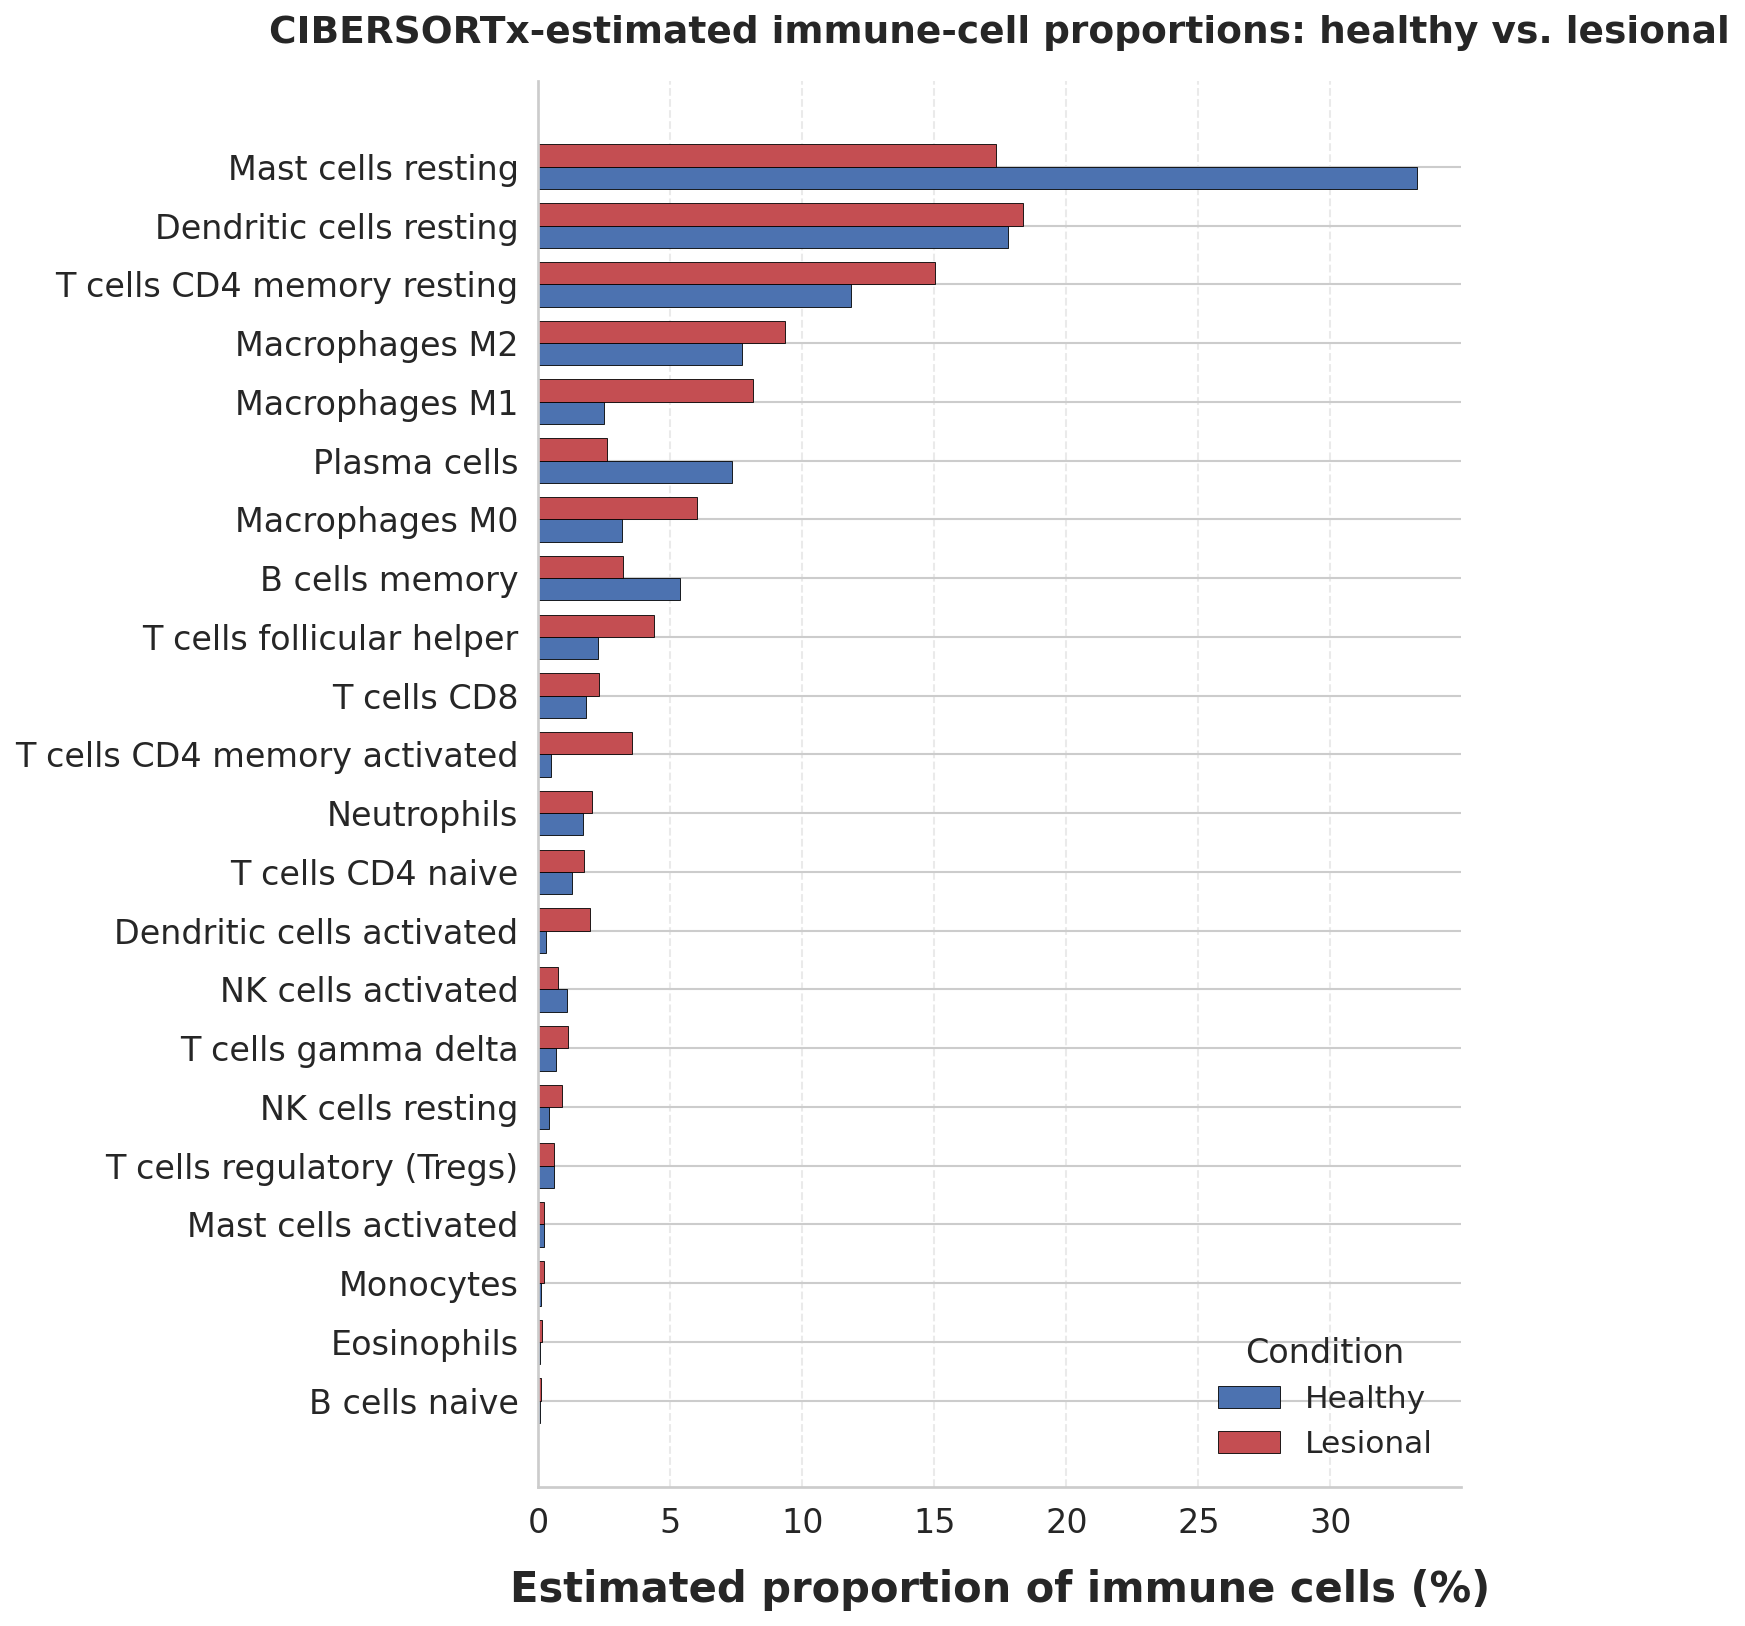

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

INPUT_DIR = Path("/content")
OUTPUT_DIR = Path("/content/cibersort_figures")
OUTPUT_DIR.mkdir(exist_ok=True)

# --- Load and merge ---
cs = pd.read_csv(INPUT_DIR / "CIBERSORTx_Job23_Results.csv")
meta = pd.read_csv(INPUT_DIR / "GSE14905_sample_metadata.csv", index_col=0)
CELL_TYPES = [c for c in cs.columns if c not in ["Mixture", "P-value", "Correlation", "RMSE"]]

df = cs.merge(meta[["condition"]], left_on="Mixture", right_index=True, how="left").dropna(subset=["condition"])
df = df[df["P-value"] <= 0.05]
df["condition"] = pd.Categorical(df["condition"], categories=["healthy", "lesional"], ordered=True)

# --- Mean fraction (as %) per cell type per condition ---
means = df.groupby("condition")[CELL_TYPES].mean() * 100

# --- Order cell types (top-to-bottom, matching image style) ---
# Pick a subset / order manually if you want to match the reference figure exactly,
# otherwise sort by overall mean abundance:
order = means.mean(axis=0).sort_values(ascending=True).index.tolist()  # ascending so largest ends up at bottom of barh

means_healthy = means.loc["healthy", order].values
means_lesional = means.loc["lesional", order].values

# --- Plot: horizontal grouped bars ---
y = np.arange(len(order))
height = 0.38

fig, ax = plt.subplots(figsize=(10, max(6, 0.5 * len(order))))

ax.barh(y - height/2, means_healthy, height, color="#4C72B0", label="Healthy",
        edgecolor="black", linewidth=0.4)
ax.barh(y + height/2, means_lesional, height, color="#C44E52", label="Lesional",
        edgecolor="black", linewidth=0.4)

# --- BIG, publication-visible labels ---
ax.set_yticks(y)
ax.set_yticklabels(order, fontsize=16)
ax.set_xlabel("Estimated proportion of immune cells (%)", fontsize=20, fontweight="bold", labelpad=14)
ax.tick_params(axis="x", labelsize=16)

ax.set_title("CIBERSORTx-estimated immune-cell proportions: healthy vs. lesional",
             fontsize=18, fontweight="bold", pad=18)

ax.legend(title="Condition", fontsize=15, title_fontsize=16, frameon=False, loc="lower right")

# Clean journal-style spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.3)
ax.spines["bottom"].set_linewidth(1.3)

ax.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "Fig_CIBERSORT_horizontal_barplot_bigfonts.png", bbox_inches="tight", dpi=300)
plt.savefig(OUTPUT_DIR / "Fig_CIBERSORT_horizontal_barplot_bigfonts.pdf", bbox_inches="tight")
plt.show()